# Basic optimisation

This is a collection of quickfire tutorials to help you get started with `PortfolioOptimisers.jl` without delving into the examples and/or documentation.

## 1. Computing returns

Usually, price data is obtained using an API, and the returns have to be computed. In `PortfolioOptimisers.jl`, we have `prices_to_returns`, which handles asset, factor, and benchmark price data, as well as implied volatilities, and volatility premiums. It performs appropriate data validation checks to ensure the data is consistent. It can also preprocess missing price data, fill gaps using [`Impute.jl`](https://github.com/invenia/Impute.jl), and collapse it to lower frequencies using [`TimeSeries.jl`](https://github.com/JuliaStats/TimeSeries.jl).

Here we show a quick example of a heterogeneous dataset that only returns data with matching timestamps.

In [1]:
using PortfolioOptimisers, CSV, TimeSeries, DataFrames, PrettyTables, LinearAlgebra,
      StableRNGs, StatsPlots, GraphRecipes
resfmt = (v, i, j) -> begin
    return if j == 1
        v
    else
        isa(v, AbstractFloat) ? "$(round(v*100, digits=3)) %" : v
    end
end;

rd = prices_to_returns(TimeArray(CSV.File(joinpath(@__DIR__, "../examples/SP500.csv.gz"));
                                 timestamp = :Date)[(end - 7 * 252):(end - 252 * 2)],
                       TimeArray(CSV.File(joinpath(@__DIR__, "../examples/Factors.csv.gz"));
                                 timestamp = :Date)[(end - 6 * 252):(end - 252)];
                       B = TimeArray(CSV.File(joinpath(@__DIR__,
                                                       "../examples/SP500_idx.csv.gz"));
                                     timestamp = :Date)[(end - 5 * 252):end])

ReturnsResult
    nx ┼ 20-element Vector{String}
     X ┼ 756×20 Matrix{Float64}
    nf ┼ Vector{String}: ["MTUM", "QUAL", "SIZE", "USMV", "VLUE"]
     F ┼ 756×5 Matrix{Float64}
    nb ┼ Vector{String}: ["SP500"]
     B ┼ 756-element Vector{Float64}
    ts ┼ 756-element Vector{Date}
    iv ┼ nothing
  ivpa ┴ nothing


The prior statistics (expected returns, per-asset volatility, and correlation matrix) give a first
impression of the data.

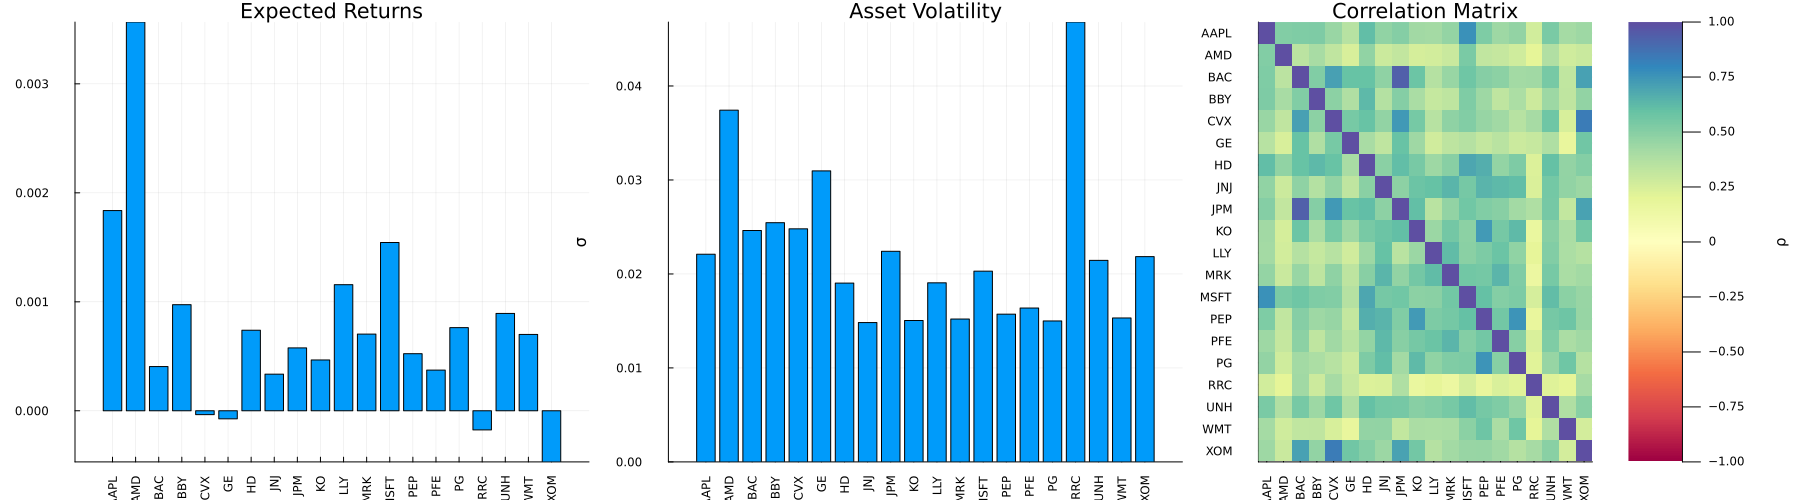

In [2]:
plot_prior(prior(EmpiricalPrior(), rd), rd)

## 2. Basic optimisations

There are many optimisers available in `PortfolioOptimisers.jl`. Here we will showcase their basic usage.

### 2.1 Naive optimisers

Naive optimisers use very basic algorithms that offer robustness and diversification by virtue of being unsophisticated.

#### 2.1.1 Inverse volatility

`InverseVolatility` uses the diagonal of the prior covariance to set the asset weights. If the property `sq` is set to `true`, the weights are the inverse of each entry in the diagonal, else it is the inverse of the square root of each entry in the diagonal.

In [3]:
# Get the variance from the prior covariance.
variance = diag(prior(EmpiricalPrior(), rd).sigma)

# Optimisers
iv1 = InverseVolatility()
iv2 = InverseVolatility(; sq = true)

# Broadcast the optimisers
ress = optimise.([iv1, iv2], rd)

# Calculate the inverse volatility and variance weights
inv_vol = 1 ./ sqrt.(variance)
inv_vol /= sum(inv_vol)
inv_var = 1 ./ variance
inv_var /= sum(inv_var)

# Display results
pretty_table(DataFrame([rd.nx ress[1].w inv_vol ress[2].w inv_var],
                       ["assets", "Opt Vol", "Inv Vol", "Opt Var", "Inv Var"]);
             formatters = [resfmt], title = "Composition")

                   Composition
┌────────┬─────────┬─────────┬─────────┬─────────┐
│ assets │ Opt Vol │ Inv Vol │ Opt Var │ Inv Var │
│    Any │     Any │     Any │     Any │     Any │
├────────┼─────────┼─────────┼─────────┼─────────┤
│   AAPL │ 4.555 % │ 4.555 % │  3.86 % │  3.86 % │
│    AMD │  2.69 % │  2.69 % │ 1.346 % │ 1.346 % │
│    BAC │ 4.088 % │ 4.088 % │ 3.108 % │ 3.108 % │
│    BBY │ 3.955 % │ 3.955 % │ 2.909 % │ 2.909 % │
│    CVX │ 4.059 % │ 4.059 % │ 3.064 % │ 3.064 % │
│     GE │  3.25 % │  3.25 % │ 1.965 % │ 1.965 % │
│     HD │  5.29 % │  5.29 % │ 5.205 % │ 5.205 % │
│    JNJ │ 6.787 % │ 6.787 % │ 8.569 % │ 8.569 % │
│    JPM │ 4.492 % │ 4.492 % │ 3.753 % │ 3.753 % │
│     KO │ 6.689 % │ 6.689 % │ 8.322 % │ 8.322 % │
│    LLY │ 5.282 % │ 5.282 % │ 5.189 % │ 5.189 % │
│    MRK │ 6.621 % │ 6.621 % │ 8.154 % │ 8.154 % │
│   MSFT │  4.96 % │  4.96 % │ 4.576 % │ 4.576 % │
│    PEP │ 6.402 % │ 6.402 % │ 7.625 % │ 7.625 % │
│      ⋮ │       ⋮ │       ⋮ │       ⋮ │       ⋮ │


Side-by-side composition of the two inverse-volatility variants.

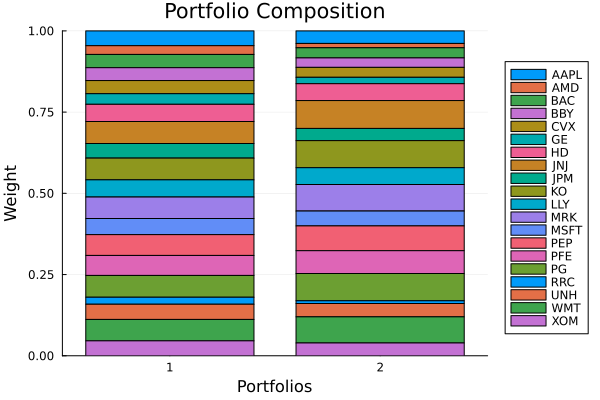

In [4]:
plot_stacked_bar_composition(ress, rd)

#### 2.1.2 Equal weighted

`EqualWeighted` assigns equal weights to all assets.

In [5]:
res = optimise(EqualWeighted(), rd)
pretty_table(DataFrame([rd.nx res.w], ["assets", "Weights"]); formatters = [resfmt],
             title = "Composition")

    Composition
┌────────┬─────────┐
│ assets │ Weights │
│    Any │     Any │
├────────┼─────────┤
│   AAPL │   5.0 % │
│    AMD │   5.0 % │
│    BAC │   5.0 % │
│    BBY │   5.0 % │
│    CVX │   5.0 % │
│     GE │   5.0 % │
│     HD │   5.0 % │
│    JNJ │   5.0 % │
│    JPM │   5.0 % │
│     KO │   5.0 % │
│    LLY │   5.0 % │
│    MRK │   5.0 % │
│   MSFT │   5.0 % │
│    PEP │   5.0 % │
│      ⋮ │       ⋮ │
└────────┴─────────┘
      6 rows omitted


#### 2.1.3 Random weighted

`RandomWeighted` assigns weights according to a [`Dirichlet`](https://juliastats.org/Distributions.jl/latest/multivariate/#Distributions.Dirichlet) distribution. The `alpha` keyword argument is forwarded to the Dirichlet distribution to control its shape. It's also possible to control the random number generator using the `rng` and `seed` keyword arguments.

In [6]:
res = optimise(RandomWeighted(; alpha = 1, rng = StableRNG(696), seed = 66420), rd)
pretty_table(DataFrame([rd.nx res.w], ["assets", "Weights"]); formatters = [resfmt],
             title = "Composition")

     Composition
┌────────┬──────────┐
│ assets │  Weights │
│    Any │      Any │
├────────┼──────────┤
│   AAPL │  2.736 % │
│    AMD │ 10.553 % │
│    BAC │    3.0 % │
│    BBY │   3.64 % │
│    CVX │  7.897 % │
│     GE │  7.176 % │
│     HD │  0.461 % │
│    JNJ │  0.014 % │
│    JPM │  3.476 % │
│     KO │  9.838 % │
│    LLY │   1.41 % │
│    MRK │  1.049 % │
│   MSFT │  9.721 % │
│    PEP │ 17.372 % │
│      ⋮ │        ⋮ │
└────────┴──────────┘
       6 rows omitted


### 2.2 JuMP optimisers

JuMP-based optimisers implement traditional mathematical optimisation algorithms using `JuMP`. As such, they are the most flexible when it comes to constraints, and for those which accept them, objective functions. Most risk measures are also compatible with these. There are a few risk measures exclusively compatible with clustering optimisations, and a few others which are incompatible for use in optimisations.

All JuMP-based optimisers require an instance of `JuMPOptimiser` with a JuMP-compatible `Solver`, or vector of solvers. Other than optimisation-specific constraints, general constraints are applied at the level of the `JuMPOptimiser`. Problem feasibility depends on the specific constraints and the provided solver's support for constraint types and ability to solve the problem.

If using open-source solvers, we recommend [`Clarabel`](https://github.com/oxfordcontrol/Clarabel.jl) when not using MIP constraints. When using MIP constraints, [`Pajarito`](https://github.com/jump-dev/Pajarito.jl) with [`Clarabel`](https://github.com/oxfordcontrol/Clarabel.jl) as the continuous solver and [`HiGHS`](https://github.com/jump-dev/HiGHS.jl) as the MIP one works very well. This makes it possible to solve problems with exotic constraint combinations.

In [7]:
using Clarabel
slv = [Solver(; name = :clarabel1, solver = Clarabel.Optimizer,
              check_sol = (; allow_local = true, allow_almost = true),
              settings = "verbose" => false),
       Solver(; name = :clarabel3, solver = Clarabel.Optimizer,
              check_sol = (; allow_local = true, allow_almost = true),
              settings = Dict("verbose" => false, "max_step_fraction" => 0.9)),
       Solver(; name = :clarabel5, solver = Clarabel.Optimizer,
              check_sol = (; allow_local = true, allow_almost = true),
              settings = Dict("verbose" => false, "max_step_fraction" => 0.80)),
       Solver(; name = :clarabel7, solver = Clarabel.Optimizer,
              check_sol = (; allow_local = true, allow_almost = true),
              settings = Dict("verbose" => false, "max_step_fraction" => 0.7)),
       Solver(; name = :clarabel8, solver = Clarabel.Optimizer,
              check_sol = (; allow_local = true, allow_almost = true),
              settings = Dict("verbose" => false, "max_step_fraction" => 0.6,
                              "max_iter" => 1500, "tol_gap_abs" => 1e-4,
                              "tol_gap_rel" => 1e-4, "tol_ktratio" => 1e-3,
                              "tol_feas" => 1e-4, "tol_infeas_abs" => 1e-4,
                              "tol_infeas_rel" => 1e-4, "reduced_tol_gap_abs" => 1e-4,
                              "reduced_tol_gap_rel" => 1e-4, "reduced_tol_ktratio" => 1e-3,
                              "reduced_tol_feas" => 1e-4, "reduced_tol_infeas_abs" => 1e-4,
                              "reduced_tol_infeas_rel" => 1e-4))];

#### 2.2.1 Mean risk

`MeanRisk` is the traditional portfolio optimisation problem. It seeks to minimise the risk with respect to a target return, or maximise the return with respect to a target risk. It supports four objective functions via the `obj` keyword which defaults to `MinimumRisk`, the risk measure(s) are specified with the `r` keyword which defaults to `Variance`.

In [8]:
# We'll use the same optimiser for all mean risk objectives
opt = JuMPOptimiser(; slv = slv)

# Minimum risk (default)
mr1 = MeanRisk(; obj = MinimumRisk(), opt = opt)

# Maximum utility
mr2 = MeanRisk(; obj = MaximumUtility(), opt = opt)

# Maximum risk adjusted return ratio
mr3 = MeanRisk(; obj = MaximumRatio(), opt = opt)

# Maximum return
mr4 = MeanRisk(; obj = MaximumReturn(), opt = opt)

# Optimise all objective functions at once using broadcasting
ress = optimise.([mr1, mr2, mr3, mr4], rd);

`PortfolioOptimisers.jl` provides users with the ability to use multiple risk measures per optimisation, which means that some risk measure have to keep certain internal statistics to be able to compute the risk.

The `MeanRisk` optimiser defaults to the variance so we will use that to compute the risk statistics. We've used the same prior statistics `EmpiricalPrior` estimator, and portfolio returns `ArithmeticReturn` estimator for all objectives. So we only need to get the ones in the first result.

Since the package's structs are all immutable, we provide factory functions that create risk measures with the appropriate internal statistics. This enables programmatic construction of risk measures, manual construction is also possible by directly using the risk measure's constructor.

In [9]:
# All priors are the same so we can use the first one
pr = ress[1].pr

# This generates the standard deviation risk measure with the right covariance matrix.
# Alternatively, we could do `StandardDeviation(; sigma = pr.sigma)`, but factory
# functions let you do this programmatically.
r = factory(StandardDeviation(), pr)

# There are `ArithmeticReturns` (default) and `LogarithmicReturns`.
ret = mr1.opt.ret

# Compute the risk, return and risk adjusted return of all results
rk_rt_ratio = [expected_risk_ret_ratio(r, ret, res.w, pr) for res in ress]
rk = map(rr -> rr[1], rk_rt_ratio)
rt = map(rr -> rr[2], rk_rt_ratio)
ratio = map(rr -> rr[3], rk_rt_ratio)

# Display asset weights
pretty_table(hcat(DataFrame(:assets => rd.nx),
                  DataFrame(reduce(hcat, [res.w for res in ress]),
                            [:MinimumRisk, :MaximumUtility, :MaximumRatio, :MaximumReturn]));
             formatters = [resfmt], title = "Composition")

# Display statistics
pretty_table(hcat(DataFrame(:Stat => ["Std", "Return", "Return/Std"]),
                  DataFrame(vcat(rk', rt', ratio'),
                            [:MinimumRisk, :MaximumUtility, :MaximumRatio, :MaximumReturn]));
             formatters = [resfmt], title = "Statistics")

                              Composition
┌────────┬─────────────┬────────────────┬──────────────┬───────────────┐
│ assets │ MinimumRisk │ MaximumUtility │ MaximumRatio │ MaximumReturn │
│ String │     Float64 │        Float64 │      Float64 │       Float64 │
├────────┼─────────────┼────────────────┼──────────────┼───────────────┤
│   AAPL │       0.0 % │       32.448 % │     31.784 % │         0.0 % │
│    AMD │       0.0 % │        46.15 % │     37.264 % │       100.0 % │
│    BAC │       0.0 % │          0.0 % │        0.0 % │         0.0 % │
│    BBY │     0.001 % │          0.0 % │        0.0 % │         0.0 % │
│    CVX │       0.0 % │          0.0 % │        0.0 % │         0.0 % │
│     GE │       0.0 % │          0.0 % │        0.0 % │         0.0 % │
│     HD │       0.0 % │          0.0 % │        0.0 % │         0.0 % │
│    JNJ │    13.325 % │          0.0 % │        0.0 % │         0.0 % │
│    JPM │       0.0 % │          0.0 % │        0.0 % │         0.0 % │
│     KO 

Portfolio compositions across all four objectives side-by-side.

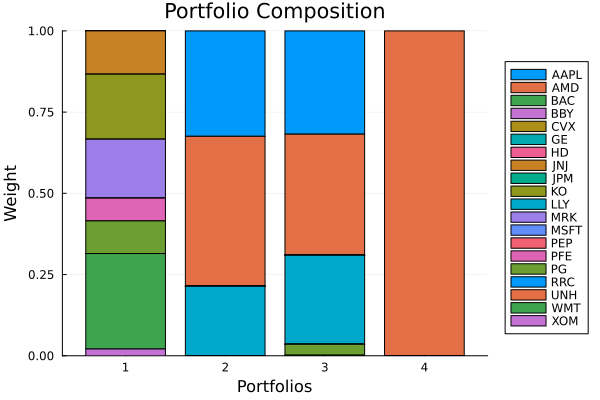

In [10]:
plot_stacked_bar_composition(ress, rd)

Per-asset standard-deviation risk contribution for the minimum-risk portfolio.

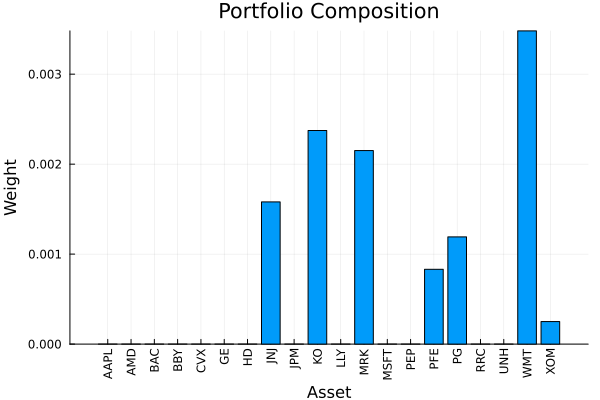

In [11]:
plot_risk_contribution(r, ress[1], rd)

#### 2.2.2 Factor risk contribution

The `FactorRiskContribution` is a more complex estimator that requires more setup. It accepts objective functions, but can also define risk contributions per factor for the variance risk measure. The minimum risk optimisation will follow the risk contribution constraints the closest. With enough data and assets, it can be quite exact up to the user-provided convergence settings for the solvers used.

It is compatible with other risk measures, but only the variance can take risk contribution constraints. Without them, or when using other risk measures, it is largely the same as the `MeanRisk` estimator.

We need to provide an instance of `AssetSets` via the `sets` keyword defining the sets of factors and their relationships. This way, the estimator can generate the linear constraints by parsing user-provided equations.

`AssetSets` is be used throughout the package for similar purposes, though mostly in the context of defining sets of assets. Other factor-based uses include combining `FactorPrior` with `EntropyPoolingPrior` and/or `BlackLittermanPrior` type prior estimators.

The `AssetSets` struct has a `key` property which defines the default search key in `dict`, `dict` must contain a key matching `key` whose value is taken to be the names of the assets/factors around which the sets are defined.

In this case, we use it to define the set of factors with key "nf" (default "nx"). We use these to define the factor risk contribution constraints, and we have to assign the linear constraint estimator for the risk contribution to the `Variance`. We'll define the constraints such that each factor contributes between 30% and 12% of the total variance risk.

In [12]:
# Define the factor sets using the "nf" key
sets = AssetSets(; key = "nf", dict = Dict("nf" => rd.nf))

# Each factor contributes `12% <= x <= 30%` of the total variance risk
lcs = LinearConstraintEstimator(;
                                val = [["0.12 <= $f" for f in rd.nf];
                                       ["$f <= 0.3" for f in rd.nf]])

# Add the linear constraint estimator to the variance risk measure
r = Variance(; rc = lcs)

Variance
  settings ┼ RiskMeasureSettings
           │   scale ┼ Float64: 1.0
           │      ub ┼ nothing
           │     rke ┴ Bool: true
     sigma ┼ nothing
      chol ┼ nothing
        rc ┼ LinearConstraintEstimator
           │   val ┼ 10-element Vector{String}
           │   key ┴ nothing
       alg ┴ SquaredSOCRiskExpr()


We can optimise for the different objective functions.

In [13]:
# We'll use the same optimiser for all factor risk contribution objectives
opt = JuMPOptimiser(; slv = slv)

# Minimum risk (default)
frc1 = FactorRiskContribution(; r = r, obj = MinimumRisk(), sets = sets, opt = opt)

# Maximum utility, `l` controls the risk aversion.
frc2 = FactorRiskContribution(; r = r, obj = MaximumUtility(; l = 8), sets = sets,
                              opt = opt)

# Maximum risk adjusted return ratio, rf is the risk free rate.
frc3 = FactorRiskContribution(; r = r, obj = MaximumRatio(; rf = 4.2 / 252 / 100),
                              sets = sets, opt = opt)

# Maximum return
frc4 = FactorRiskContribution(; r = r, obj = MaximumReturn(), sets = sets, opt = opt)

# Optimise all objective functions at once using broadcasting
ress = optimise.([frc1, frc2, frc3, frc4], rd);

We can display the results and factor risk contributions `factor_risk_contribution`, but we have to normalise them using their sum. Again we use the factory function to set the appropriate internal parameters. The last entry in the risk contribution is the regression intercept.

In [14]:
# Generate the risk measure with the right covariance matrix
r = factory(r, pr)

# Compute and normalise the factor risk contributions
rkcs = [factor_risk_contribution(r, res.w, pr.X; rd = rd) for res in ress]
rkcs = rkcs ./ sum.(rkcs)

# Display asset weights
pretty_table(hcat(DataFrame(:assets => rd.nx),
                  DataFrame(reduce(hcat, [res.w for res in ress]),
                            [:MinimumRisk, :MaximumUtility, :MaximumRatio, :MaximumReturn]));
             formatters = [resfmt], title = "Composition")

# Display factor risk contributions
pretty_table(hcat(DataFrame(:factors => [rd.nf; "Intercept"]),
                  DataFrame(reduce(hcat, rkcs),
                            ["RC MinRisk", "RC Max Util", "RC Max Ratio", "RC Max Ret"]));
             formatters = [resfmt], title = "Factor Risk Contributions")

                              Composition
┌────────┬─────────────┬────────────────┬──────────────┬───────────────┐
│ assets │ MinimumRisk │ MaximumUtility │ MaximumRatio │ MaximumReturn │
│ String │     Float64 │        Float64 │      Float64 │       Float64 │
├────────┼─────────────┼────────────────┼──────────────┼───────────────┤
│   AAPL │      1.12 % │        1.382 % │      8.372 % │      11.873 % │
│    AMD │     8.315 % │        12.22 % │     12.164 % │      21.114 % │
│    BAC │     2.779 % │        0.618 % │      4.591 % │       1.162 % │
│    BBY │       4.1 % │        3.574 % │      5.802 % │       5.427 % │
│    CVX │     9.866 % │       10.406 % │        0.0 % │       5.296 % │
│     GE │     4.071 % │          2.3 % │      1.443 % │         0.0 % │
│     HD │    10.868 % │       13.242 % │      3.257 % │      10.359 % │
│    JNJ │     1.199 % │          0.0 % │      5.253 % │       1.335 % │
│    JPM │     4.265 % │        2.667 % │       2.85 % │       1.196 % │
│     KO 

Portfolio compositions for each FactorRiskContribution objective.

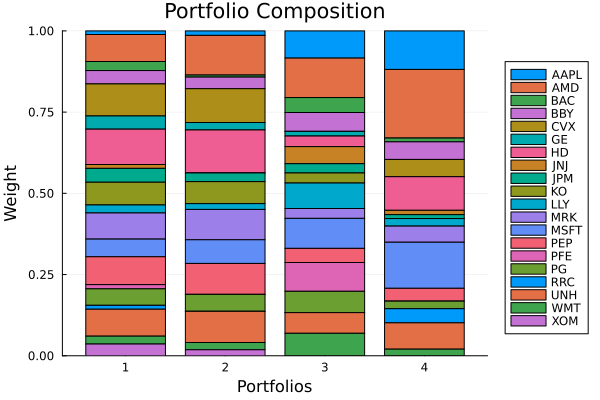

In [15]:
plot_stacked_bar_composition(ress, rd)

Factor risk contribution bar chart for the minimum-risk portfolio. The last bar is the intercept term.

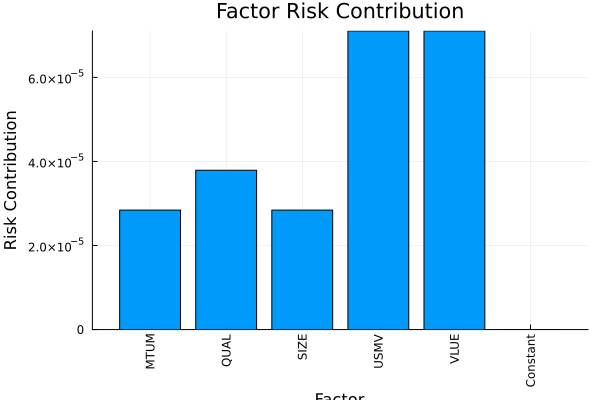

In [16]:
plot_factor_risk_contribution(r, ress[1], rd)

#### 2.2.3 Near optimal centering

`NearOptimalCentering` is a way to smear an optimal portfolio within a region around the point of optimality. The size of this region can be tuned by the user via the `bins` keyword, or automatically decided based on the number of observations and assets (default). This makes the portfolio more robust to estimation error and more diversified. It is not compatible with risk measures which produce quadratic risk expressions, so the risk measure keyword `r` defaults to `StandardDeviation`.

There are two variants, defined by the `alg` keyword, one which applies all constraints to the inner `MeanRisk` optimisation and leaves the near optimal portfolio to fall where it may `UnconstrainedNearOptimalCentering`, meaning the constraints will not be satisfied by the near optimal portfolio. The second variant applies the constraints to the near optimal portfolio as well `ConstrainedNearOptimalCentering`.

In [17]:
# We'll use the standard deviation risk measure, risk measures
# that generate quadratic expressions do not work with `NearOptimalCentering`
r = StandardDeviation()

# We'll use the same optimiser for all optimisations
opt = JuMPOptimiser(; slv = slv)

# Minimum risk (default)
noc1 = NearOptimalCentering(; obj = MinimumRisk(), opt = opt)

# Maximum utility
noc2 = NearOptimalCentering(; obj = MaximumUtility(; l = 0.5), opt = opt)

# Maximum risk adjusted return ratio
noc3 = NearOptimalCentering(; obj = MaximumRatio(), opt = opt)

# Maximum return
noc4 = NearOptimalCentering(; obj = MaximumReturn(), opt = opt)

# Optimise all objective functions at once using broadcasting
ress = optimise.([noc1, noc2, noc3, noc4], rd);

View and compute the results.

In [18]:
# Prior statistics result, we will use the covariance matrix, `sigma`
pr = ress[1].pr

# This generates the standard deviation risk measure with the right covariance matrix.
# Alternatively, we could do `StandardDeviation(; sigma = pr.sigma)`, but factory
# functions let you do this programmatically.
r = factory(StandardDeviation(), pr)

# There are `ArithmeticReturns` (default) and `LogarithmicReturns`.
ret = mr1.opt.ret

# Compute the risk, return and risk adjusted return of all results
rk_rt_ratio = [expected_risk_ret_ratio(r, ret, res.w, pr) for res in ress]
rk = map(rr -> rr[1], rk_rt_ratio)
rt = map(rr -> rr[2], rk_rt_ratio)
ratio = map(rr -> rr[3], rk_rt_ratio)

# Display asset weights
pretty_table(hcat(DataFrame(:assets => rd.nx),
                  DataFrame(reduce(hcat, [res.w for res in ress]),
                            [:MinimumRisk, :MaximumUtility, :MaximumRatio, :MaximumReturn]));
             formatters = [resfmt], title = "Composition")

# Display statistics
pretty_table(hcat(DataFrame(:Stat => ["Std", "Return", "Return/Std"]),
                  DataFrame(vcat(rk', rt', ratio'),
                            [:MinimumRisk, :MaximumUtility, :MaximumRatio, :MaximumReturn]));
             formatters = [resfmt], title = "Statistics")

                              Composition
┌────────┬─────────────┬────────────────┬──────────────┬───────────────┐
│ assets │ MinimumRisk │ MaximumUtility │ MaximumRatio │ MaximumReturn │
│ String │     Float64 │        Float64 │      Float64 │       Float64 │
├────────┼─────────────┼────────────────┼──────────────┼───────────────┤
│   AAPL │      2.27 % │        3.728 % │     18.433 % │       0.241 % │
│    AMD │     1.479 % │        3.318 % │     42.803 % │      97.341 % │
│    BAC │      1.28 % │        1.393 % │       0.88 % │       0.125 % │
│    BBY │     2.149 % │         2.45 % │      1.479 % │       0.154 % │
│    CVX │     1.479 % │         1.43 % │      0.671 % │       0.109 % │
│     GE │     1.653 % │        1.546 % │      0.675 % │       0.108 % │
│     HD │     2.472 % │        2.628 % │      1.303 % │       0.141 % │
│    JNJ │     8.507 % │        6.183 % │      1.376 % │       0.123 % │
│    JPM │       1.7 % │        1.905 % │      1.199 % │       0.133 % │
│     KO 

Portfolio compositions for each NearOptimalCentering objective.

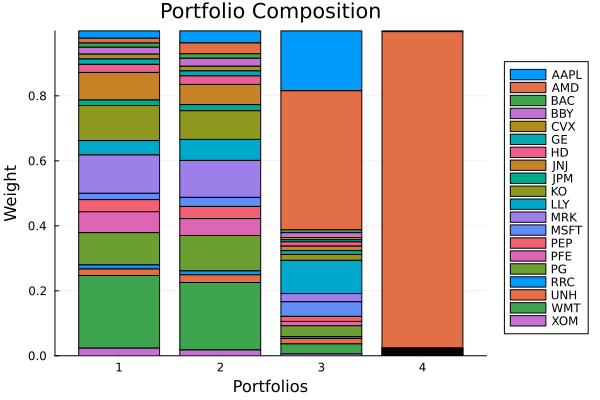

In [19]:
plot_stacked_bar_composition(ress, rd)

#### 2.2.4 Risk budgeting

`RiskBudgeting` provides a way to allocate risk across assets or factors via the `rba` keyword according to a user-defined risk budgeting vector provided via the `rkb` keyword of `AssetRiskBudgeting` and `FactorRiskBudgeting` risk budgeting algorithms. The risk budget vectors do not have to be normalised. The risk being budgeted depends on the risk measures used. This does not support objective functions, the optimisation is solely focused on achieving the risk budgeting as closely as possible. It is compatible with the same risk measures as `MeanRisk`.

##### 2.2.4.1 Asset risk budgeting

This version allocates risk across assets.

In [20]:
# We'll use the variance risk measure.
r = Variance()

# We'll use the same optimiser for all optimisations
opt = JuMPOptimiser(; slv = slv)

# Equal risk contribution per asset (default)
rba1 = RiskBudgeting(; r = r,
                     rba = AssetRiskBudgeting(;
                                              rkb = RiskBudget(;
                                                               val = fill(1.0,
                                                                          length(rd.nx)))),
                     opt = opt)

# Increasing risk contribution per asset
rba2 = RiskBudgeting(; r = r,
                     rba = AssetRiskBudgeting(; rkb = RiskBudget(; val = 1:length(rd.nx))),
                     opt = opt)

# Optimise all risk budgeting estimators at once using broadcasting
ress = optimise.([rba1, rba2], rd);

View and compute the results.

In [21]:
# All priors are the same so we can use the first one
pr = ress[1].pr

# Generate the risk measure with the appropriate covariance matrix
r = factory(r, pr)

# Compute and normalise the asset risk contributions
rkcs = [risk_contribution(r, res.w, pr.X) for res in ress]
rkcs = rkcs ./ sum.(rkcs)

# Display the results
pretty_table(hcat(DataFrame(:assets => rd.nx),
                  DataFrame(reduce(hcat, [[res.w rkc] for (res, rkc) in zip(ress, rkcs)]),
                            ["Eq Risk Weights", "Eq Risk Budget", "Incr Risk Weights",
                             "Incr Risk Budget"])); formatters = [resfmt])

┌────────┬─────────────────┬────────────────┬───────────────────┬───────────────
│ assets │ Eq Risk Weights │ Eq Risk Budget │ Incr Risk Weights │ Incr Risk Bu ⋯
│ String │         Float64 │        Float64 │           Float64 │          Flo ⋯
├────────┼─────────────────┼────────────────┼───────────────────┼───────────────
│   AAPL │         4.386 % │          5.0 % │           0.429 % │          0.4 ⋯
│    AMD │         3.475 % │          5.0 % │           0.732 % │          0.9 ⋯
│    BAC │         3.611 % │          5.0 % │           1.027 % │          1.4 ⋯
│    BBY │         4.226 % │          5.0 % │           1.675 % │          1.9 ⋯
│    CVX │         3.773 % │          5.0 % │           1.765 % │          2.3 ⋯
│     GE │         3.806 % │          5.0 % │            2.22 % │          2.8 ⋯
│     HD │         4.705 % │          5.0 % │           3.129 % │          3.3 ⋯
│    JNJ │         6.437 % │          5.0 % │           4.603 % │          3.8 ⋯
│    JPM │         3.982 % │

Asset risk contributions confirm that the equal-budget portfolio distributes variance evenly,
while the increasing-budget portfolio skews towards higher-weighted assets.

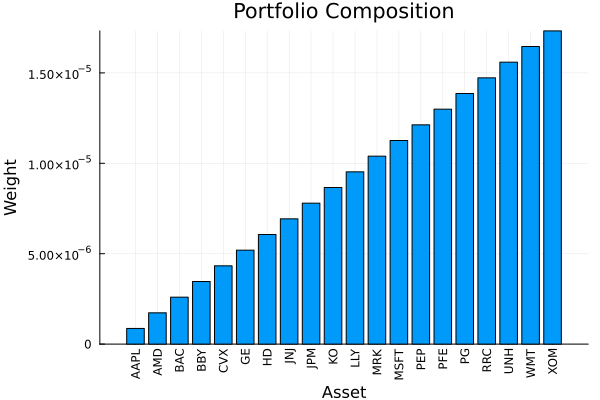

In [22]:
plot_risk_contribution(r, ress[1], rd)
plot_risk_contribution(r, ress[2], rd)

##### 2.2.4.1 Factor risk budgeting

This version allocates risk across factors.

In [23]:
# We'll use the variance risk measure.
r = Variance()

# We'll use the same optimiser for all optimisations
opt = JuMPOptimiser(; slv = slv)

# Equal risk contribution per factor (default)
rba1 = RiskBudgeting(; r = r,
                     rba = FactorRiskBudgeting(;
                                               rkb = RiskBudget(;
                                                                val = range(; start = 1,
                                                                            stop = 1,
                                                                            length = length(rd.nf)))),
                     opt = opt)

# Increasing risk contribution per factor
rba2 = RiskBudgeting(; r = r,
                     rba = FactorRiskBudgeting(; rkb = RiskBudget(; val = 1:length(rd.nf))),
                     opt = opt)

# Optimise all risk budgeting estimators at once using broadcasting
ress = optimise.([rba1, rba2], rd);

View and compute the results.

In [24]:
# All priors are the same so we can use the first one
pr = ress[1].pr

# Generate the risk measure with the appropriate covariance matrix
r = factory(r, pr)

# Compute and normalise the asset risk contributions
rkcas = [risk_contribution(r, res.w, pr.X) for res in ress]
rkcas = rkcas ./ sum.(rkcas)

# Compute and normalise the factor risk contributions
rkcfs = [factor_risk_contribution(r, res.w, pr.X; rd = rd) for res in ress]
rkcfs = rkcfs ./ sum.(rkcfs)

# Display the asset risk contributions
pretty_table(hcat(DataFrame(:assets => rd.nx),
                  DataFrame(reduce(hcat, [[res.w rkc] for (res, rkc) in zip(ress, rkcas)]),
                            ["Eq Risk Weights", "Eq Risk Budget", "Incr Risk Weights",
                             "Incr Risk Budget"])); formatters = [resfmt],
             title = "Asset risk contribution")

# Display the factor risk contributions
pretty_table(hcat(DataFrame(:factors => [rd.nf; "Intercept"]),
                  DataFrame(reduce(hcat,
                                   [[[(res.prb.b1 \ res.w); NaN] rkc]
                                    for (res, rkc) in zip(ress, rkcfs)]),
                            ["Eq Risk Weights", "Eq Risk Budget", "Incr Risk Weights",
                             "Incr Risk Budget"])); formatters = [resfmt],
             title = "Factor risk contribution")

                            Asset risk contribution
┌────────┬─────────────────┬────────────────┬───────────────────┬───────────────
│ assets │ Eq Risk Weights │ Eq Risk Budget │ Incr Risk Weights │ Incr Risk Bu ⋯
│ String │         Float64 │        Float64 │           Float64 │          Flo ⋯
├────────┼─────────────────┼────────────────┼───────────────────┼───────────────
│   AAPL │         2.518 % │        2.617 % │             0.0 % │            0 ⋯
│    AMD │         3.202 % │        4.295 % │           3.644 % │          4.7 ⋯
│    BAC │         2.928 % │        3.596 % │           9.572 % │         12.5 ⋯
│    BBY │         1.884 % │        2.013 % │           3.022 % │          3.2 ⋯
│    CVX │         8.983 % │       11.033 % │           7.751 % │          9.7 ⋯
│     GE │         2.945 % │        3.334 % │           4.587 % │          5.6 ⋯
│     HD │        22.721 % │       24.027 % │           19.13 % │         19.7 ⋯
│    JNJ │           0.0 % │          0.0 % │            

Factor risk contributions for the equal-budget and increasing-budget factor risk portfolios.

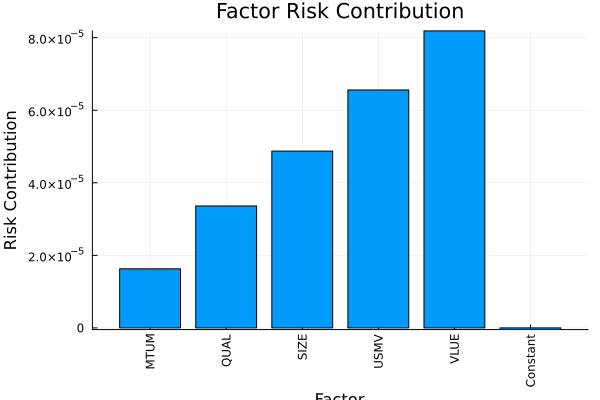

In [25]:
plot_factor_risk_contribution(r, ress[1], rd)
plot_factor_risk_contribution(r, ress[2], rd)

#### 2.2.5 Relaxed risk budgeting

`RelaxedRiskBudgeting` provides a way to allocate risk across assets or factors according to a user-defined risk budgeting vector, which does not have to be normalised. They are provided in the same way as for `RiskBudgeting`, it does not accept risk measures as it's only available for the variance, and it will not follow the risk budget as closely.

There are three variants, basic, regularised, and regularised and penalised. Since the asset and factor versions are the same as before we will only show the different relaxed risk budgeting algorithms.

In [26]:
# We'll use the same optimiser for all optimisations
opt = JuMPOptimiser(; slv = slv)

# Basic
rrb1 = RelaxedRiskBudgeting(;
                            rba = AssetRiskBudgeting(;
                                                     rkb = RiskBudget(;
                                                                      val = range(;
                                                                                  start = 1,
                                                                                  stop = 1,
                                                                                  length = length(rd.nx)))),
                            alg = BasicRelaxedRiskBudgeting(), opt = opt)

# Regularised
rrb2 = RelaxedRiskBudgeting(;
                            rba = AssetRiskBudgeting(;
                                                     rkb = RiskBudget(;
                                                                      val = range(;
                                                                                  start = 1,
                                                                                  stop = 1,
                                                                                  length = length(rd.nx)))),
                            alg = RegularisedRelaxedRiskBudgeting(), opt = opt)

# Regularised and penalised, `p` is the penalty factor (default 1)
rrrb3 = RelaxedRiskBudgeting(;
                             rba = AssetRiskBudgeting(;
                                                      rkb = RiskBudget(;
                                                                       val = range(;
                                                                                   start = 1,
                                                                                   stop = 1,
                                                                                   length = length(rd.nx)))),
                             alg = RegularisedPenalisedRelaxedRiskBudgeting(; p = 1),
                             opt = opt)

# Optimise all relaxed risk budgeting estimators at once using broadcasting
ress = optimise.([rrb1, rrb2, rrrb3], rd);

View and compute the results.

In [27]:
# All priors are the same so we can use the first one
pr = ress[1].pr

# Generate the risk measure with the appropriate covariance matrix
r = factory(StandardDeviation(), pr)

# Compute and normalise the risk contributions for each estimator
rkcs = [risk_contribution(r, res.w, pr.X) for res in ress]
rkcs = rkcs ./ sum.(rkcs)

# Display the results
pretty_table(hcat(DataFrame(:assets => rd.nx),
                  DataFrame(reduce(hcat, [[res.w rkc] for (res, rkc) in zip(ress, rkcs)]),
                            ["B Weights", "B Budget", "Reg Weights", "Reg Budget",
                             "RegPen Weights", "RegPen Budget"])); formatters = [resfmt])

┌────────┬───────────┬──────────┬─────────────┬────────────┬────────────────┬───
│ assets │ B Weights │ B Budget │ Reg Weights │ Reg Budget │ RegPen Weights │  ⋯
│ String │   Float64 │  Float64 │     Float64 │    Float64 │        Float64 │  ⋯
├────────┼───────────┼──────────┼─────────────┼────────────┼────────────────┼───
│   AAPL │   2.445 % │   2.92 % │     1.697 % │    2.002 % │        2.969 % │  ⋯
│    AMD │   2.028 % │   2.92 % │     1.445 % │    2.002 % │        2.431 % │  ⋯
│    BAC │   2.088 % │   2.92 % │     1.463 % │    2.002 % │        2.494 % │  ⋯
│    BBY │   2.434 % │   2.92 % │     1.718 % │    2.002 % │        2.926 % │  ⋯
│    CVX │   2.214 % │   2.92 % │     1.558 % │    2.002 % │         2.63 % │  ⋯
│     GE │   2.282 % │   2.92 % │     1.622 % │    2.002 % │        2.683 % │  ⋯
│     HD │   2.583 % │   2.92 % │      1.78 % │    2.002 % │        3.157 % │  ⋯
│    JNJ │   7.688 % │  6.895 % │     9.706 % │    9.151 % │        9.168 % │  ⋯
│    JPM │   2.292 % │   2.9

Compositions across the three relaxed risk budgeting variants.

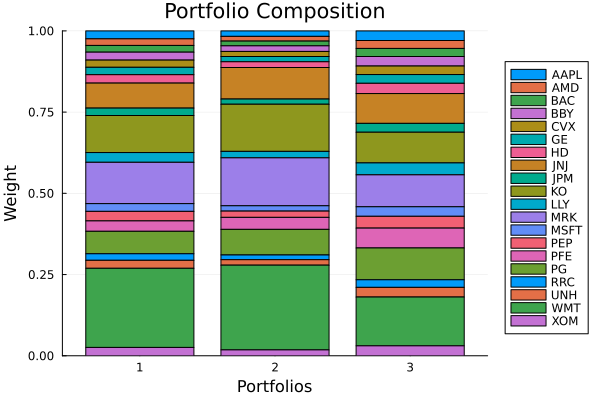

In [28]:
plot_stacked_bar_composition(ress, rd)

### 2.3 Clustering optimisers

Clustering based optimisers use the relationship structure between assets. The weights are a function of the risks associated with those structures. Aside from the `NestedClustered` estimator, they all use an instance of `HierarchicalOptimiser` which defines common parameters for all clustering optimisers. `HierarchicalOptimiser` does not require a solver to be specified via the `slv` keyword unless the clustering optimisation estimator uses a risk measure that requires one.

#### 2.3.1 Hierarchical risk parity

The `HierarchicalRiskParity` estimator uses the hierarchical structure of the assets to iteratively partition the assets into smaller and smaller clusters until reaching a leaf node. The weights are computed as a function of the risk between left and right cluster at each partition level. This accepts the same risk measures as JuMP based optimisers, plus some extra ones for which there are no traditional optimisation formulations.

The `HierarchicalOptimiser` can be specified via the `opt` keyword, and the risk measure can be specified via the `r` keyword which defaults to the `Variance`.

In [29]:
# Hierarchical risk parity
hrp = HierarchicalRiskParity()

# Optimise the hierarchical risk parity model
res = optimise(hrp, rd);

View and compute the results.

In [30]:
# Construct the variance with the appropriate covariance matrix
pr = res.pr
r = factory(StandardDeviation(), pr)

# Compute the risk, return and risk adjusted return
rk, rt, ratio = expected_risk_ret_ratio(r, ArithmeticReturn(), res.w, pr)

# Display hierarchical risk parity weights
pretty_table(DataFrame(:assets => rd.nx, :Weights => res.w); formatters = [resfmt],
             title = "Composition")

# Display risk, return and risk adjusted return
pretty_table(DataFrame(:Stat => ["Std", "Return", "Return/Std"],
                       :Measure => [rk, rt, ratio]); formatters = [resfmt],
             title = "Statistics")

    Composition
┌────────┬─────────┐
│ assets │ Weights │
│ String │ Float64 │
├────────┼─────────┤
│   AAPL │ 4.612 % │
│    AMD │ 1.378 % │
│    BAC │ 3.001 % │
│    BBY │ 3.707 % │
│    CVX │ 3.186 % │
│     GE │ 2.013 % │
│     HD │ 6.219 % │
│    JNJ │ 9.316 % │
│    JPM │ 3.624 % │
│     KO │ 5.824 % │
│    LLY │ 5.857 % │
│    MRK │ 8.865 % │
│   MSFT │ 3.198 % │
│    PEP │ 8.275 % │
│      ⋮ │       ⋮ │
└────────┴─────────┘
      6 rows omitted
       Statistics
┌────────────┬─────────┐
│       Stat │ Measure │
│     String │ Float64 │
├────────────┼─────────┤
│        Std │ 1.333 % │
│     Return │  0.07 % │
│ Return/Std │ 5.234 % │
└────────────┴─────────┘


The hierarchical clustering dendrogram shows which assets were grouped together.

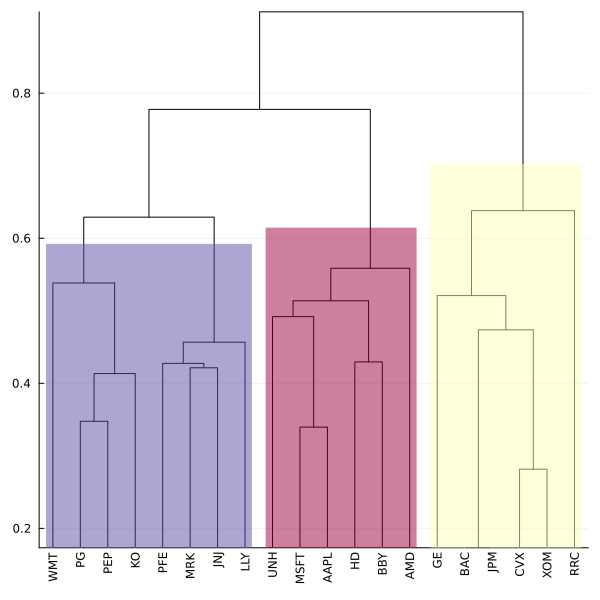

In [31]:
plot_dendrogram(res.clr, rd.nx)

Portfolio composition and per-asset risk contribution for HRP.

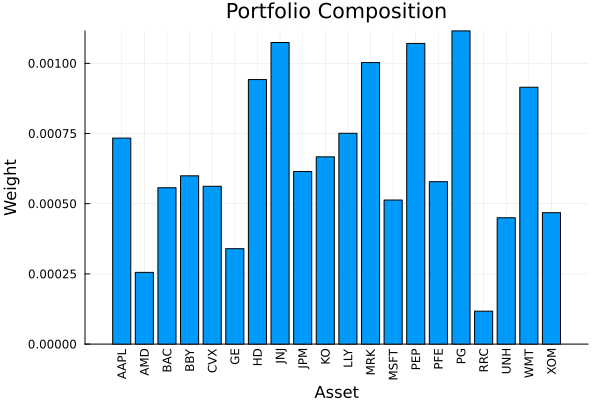

In [32]:
plot_composition(res, rd)
plot_risk_contribution(r, res, rd)

#### 2.3.2 Schur complement hierarchical risk parity

The `SchurComplementHierarchicalRiskParity` estimator works similarly to `HierarchicalRiskParity`, but uses the Schur complement to decide whether or not to include more information into the risk calculation. It is only available for the variance and standard deviation because it relies on the Schur complement.

It serves almost as an interpolation between the classic mean variance optimisation and hierarchical risk parity. It has a `params` keyword which allows users to specify an instance, or vector of instances of `SchurComplementParams` which specify the risk measure, the "interpolation" parameter `gamma ∈ [0, 1]`, and whether the algorithm should be kept monotonic in risk as `gamma` increases (default).

When `gamma` is `0`, it reduces to the `HierarchicalRiskParity` estimator, the closer it is to `1` the closer it is to the classic mean variance optimisation. It's worth noting that there are values of `gamma` for which the Schur augmented matrix may not be positive definite, as it cannot add any more risk information beyond a certain point. So if one wants `gamma` to be large, one should use `NonMonotonicSchurComplement` and make sure to disable the positive definite projection in the `pdm` keyword of `SchurComplementParams`.

In [33]:
# We can also use the standard deviation
r = Variance()

# Hierarchical risk parity
hrp = HierarchicalRiskParity()

# Schur complement hierarchical risk parity converging to the hierarchical risk parity
sch1 = SchurComplementHierarchicalRiskParity(;
                                             params = SchurComplementParams(; gamma = 0,
                                                                            r = r,
                                                                            alg = MonotonicSchurComplement()))

# Mean variance optimisation
mr = MeanRisk(; opt = JuMPOptimiser(; slv = slv))

# Schur complement hierarchical risk parity nearing the mean variance optimisation, no positive definite projection, non-monotonic
sch2 = SchurComplementHierarchicalRiskParity(;
                                             params = SchurComplementParams(; gamma = 1,
                                                                            r = r,
                                                                            pdm = nothing,
                                                                            alg = NonMonotonicSchurComplement()))

# Schur complement hierarchical risk parity nearing the mean variance optimisation, monotonic
sch3 = SchurComplementHierarchicalRiskParity(;
                                             params = SchurComplementParams(; gamma = 1,
                                                                            r = r,
                                                                            alg = MonotonicSchurComplement()))

# Optimise all optimisers at once using broadcasting
ress = optimise.([hrp, sch1, mr, sch2, sch3], rd);

We can compute the statistics and visualise the results of each estimator.

In [34]:
# All priors are the same so we can use the first one
pr = ress[1].pr

# Generate the risk measure with the appropriate covariance matrix
r = factory(StandardDeviation(), pr)

# Compute the risk, return and risk adjusted return of all results
rk_rt_ratio = [expected_risk_ret_ratio(r, ArithmeticReturn(), res.w, pr) for res in ress]
rk = map(rr -> rr[1], rk_rt_ratio)
rt = map(rr -> rr[2], rk_rt_ratio)
ratio = map(rr -> rr[3], rk_rt_ratio)

# Display asset weights
pretty_table(hcat(DataFrame(:assets => rd.nx),
                  DataFrame(reduce(hcat, [res.w for res in ress]),
                            ["HRP", "gamma = 0", "MVO", "gamma = 1", "gamma = :max"]));
             formatters = [resfmt], title = "Composition")

# Display statistics
pretty_table(hcat(DataFrame(:Stat => ["Std", "Return", "Return/Std"]),
                  DataFrame(vcat(rk', rt', ratio'),
                            ["HRP", "gamma = 0", "MVO", "gamma = 1", "gamma = :max"]));
             formatters = [resfmt], title = "Statistics")

                             Composition
┌────────┬─────────┬───────────┬──────────┬───────────┬──────────────┐
│ assets │     HRP │ gamma = 0 │      MVO │ gamma = 1 │ gamma = :max │
│ String │ Float64 │   Float64 │  Float64 │   Float64 │      Float64 │
├────────┼─────────┼───────────┼──────────┼───────────┼──────────────┤
│   AAPL │ 4.612 % │   4.612 % │    0.0 % │   0.258 % │      7.401 % │
│    AMD │ 1.378 % │   1.378 % │    0.0 % │   3.115 % │      0.065 % │
│    BAC │ 3.001 % │   3.001 % │    0.0 % │   0.106 % │      2.364 % │
│    BBY │ 3.707 % │   3.707 % │  0.001 % │     0.0 % │      0.319 % │
│    CVX │ 3.186 % │   3.186 % │    0.0 % │     0.0 % │      0.365 % │
│     GE │ 2.013 % │   2.013 % │    0.0 % │   0.917 % │      0.092 % │
│     HD │ 6.219 % │   6.219 % │    0.0 % │   0.591 % │      9.668 % │
│    JNJ │ 9.316 % │   9.316 % │ 13.325 % │     0.0 % │     14.118 % │
│    JPM │ 3.624 % │   3.624 % │    0.0 % │   0.117 % │      2.943 % │
│     KO │ 5.824 % │   5.824 % │ 20.

Compositions across HRP, Schur complement variants, and MVO — showing how `gamma` interpolates
between HRP (γ=0) and mean-variance optimisation (γ=1).

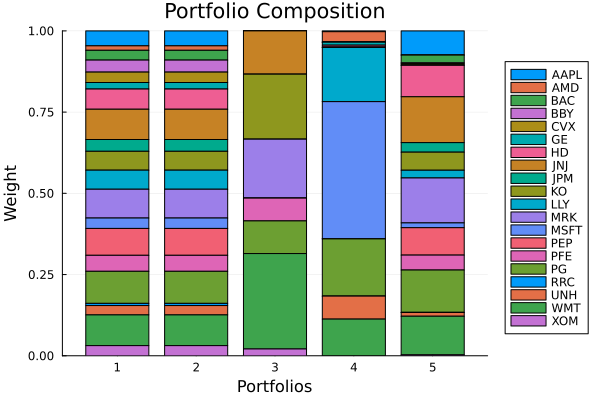

In [35]:
plot_stacked_bar_composition(ress, rd)

#### 2.3.3 Hierarchical equal risk contribution

The `HierarchicalEqualRiskContribution` estimator uses the hierarchical structure of the assets as well as a score of clustering quality to iteratively break up the asset universe into left and right clusters up until the optimal number of clusters according to the score. Each cluster is treated as a synthetic asset for which the risk is computed. The weight of each cluster is computed based on the risk it represents with respect to the cluster on the other side. The risks of each asset in the cluster are also computed, and the weights computed off of these. The per-asset weights are multiplied by the weight associated with the cluster as a whole. This is repeated for every clustering level until the optimal number of clusters is reached.

The `HierarchicalOptimiser` is specified via the `opt` keyword. Since this optimiser breaks up the assets into intra- and inter-cluster optimisations, it's possible to provide inner and outer risk measures via the `ri` and `ro` keywords, both default to the `Variance`.

This optimiser got its name from the fact that the original formulation assigned equal weights to the assets within each cluster, while the outer optimisation used the variance. This is a generalization of that formulation.

In [36]:
using Clustering

# Original Hierarchical equal risk contribution, equal weights as the risk inner risk measure, variance for the outer one
herc1 = HierarchicalEqualRiskContribution(; ri = EqualRiskMeasure(), ro = Variance())

# Flip the original Hierarchical equal risk contribution, equal weights as the risk outer risk measure, variance for the inner one
herc2 = HierarchicalEqualRiskContribution(; ro = EqualRiskMeasure(), ri = Variance())

# Optimise all optimisers at once using broadcasting
ress = optimise.([herc1, herc2], rd);

We can view the results and verify that for the originsl formulation, all assets within a single cluster have the same weight.

In [37]:
# All priors are the same so we can use the first one
pr = ress[1].pr

# Generate the risk measure with the appropriate covariance matrix
r = factory(StandardDeviation(), pr)

# Compute the risk, return and risk adjusted return of all results
rk_rt_ratio = [expected_risk_ret_ratio(r, ArithmeticReturn(), res.w, pr) for res in ress]
rk = map(rr -> rr[1], rk_rt_ratio)
rt = map(rr -> rr[2], rk_rt_ratio)
ratio = map(rr -> rr[3], rk_rt_ratio)

# Display asset weights and clustering assignments
pretty_table(DataFrame(:assets => rd.nx, :cluster => assignments(res.clr),
                       :Original => ress[1].w, :Flipped => ress[2].w);
             formatters = [resfmt], title = "Composition")

# Display statistics
pretty_table(hcat(DataFrame(:Stat => ["Std", "Return", "Return/Std"]),
                  DataFrame(vcat(rk', rt', ratio'), [:Original, :Flipped]));
             formatters = [resfmt], title = "Statistics")

               Composition
┌────────┬─────────┬──────────┬──────────┐
│ assets │ cluster │ Original │  Flipped │
│ String │   Int64 │  Float64 │  Float64 │
├────────┼─────────┼──────────┼──────────┤
│   AAPL │       1 │  2.618 % │  2.925 % │
│    AMD │       1 │  2.618 % │   1.02 % │
│    BAC │       2 │  8.474 % │ 12.407 % │
│    BBY │       1 │  2.618 % │  2.205 % │
│    CVX │       2 │  8.474 % │ 12.232 % │
│     GE │       2 │  8.474 % │  7.845 % │
│     HD │       1 │  2.618 % │  3.944 % │
│    JNJ │       3 │  4.181 % │   2.33 % │
│    JPM │       2 │  8.474 % │ 14.982 % │
│     KO │       3 │  4.181 % │  2.263 % │
│    LLY │       3 │  4.181 % │  1.411 % │
│    MRK │       3 │  4.181 % │  2.217 % │
│   MSFT │       1 │  2.618 % │  3.468 % │
│    PEP │       3 │  4.181 % │  2.073 % │
│      ⋮ │       ⋮ │        ⋮ │        ⋮ │
└────────┴─────────┴──────────┴──────────┘
                            6 rows omitted
            Statistics
┌────────────┬──────────┬─────────┐
│       Sta

The dendrogram and reordered correlation heatmap show the cluster structure used by HERC.

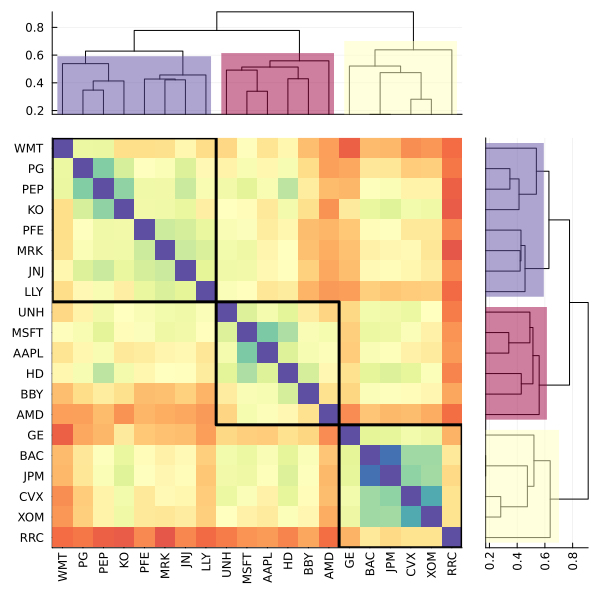

In [38]:
plot_dendrogram(ress[1].clr, rd.nx)
plot_clusters(ress[1].clr, rd.nx)

Side-by-side compositions for original and flipped HERC.

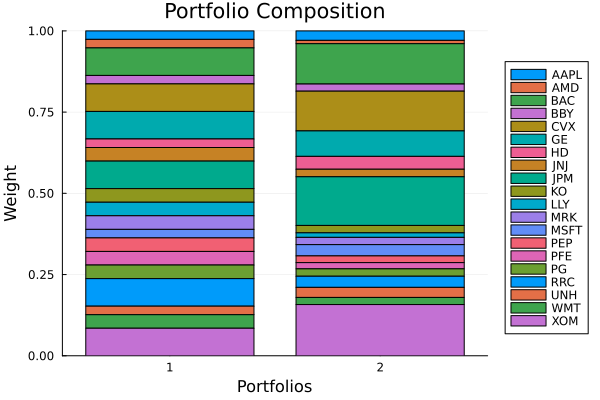

In [39]:
plot_stacked_bar_composition(ress, rd)

#### 2.3.4 Nested clustered

The `NestedClustered` optimiser uses the same idea as the `HierarchicalEqualRiskContribution`, where the optimisation process is split into inner and outer optimisations using the same scoring system for finding the optimal number of clusters. However, unlike `HierarchicalEqualRiskContribution`, the intra- and inter-cluster optimisations are completely independent. It is possible to provide any non-finite allocation optimisation estimator for the inner and outer estimators independently via the keywords `opti` and `opto` respectively. This means it inherits the requirements for the inner and outer estimators respectively.

It is also possible to optimise the outer estimator by using cross-validation via the `cv` keyword. If provided, a cross-validation prediction is applied to the inner estimators, yielding a predicted returns series for each cluster. The returns vector for each cluster is then taken as the returns vector for a synthetic asset. These are placed into a matrix which is used to optimise the outer estimator. When not using a cross-validation approach, the returns of the synthetic assets are computed directly by multiplying the original returns matrix by an `N × C` matrix, where `N` is the number of assets and `C` is the number of clusters. This weights matrix contains the inner weights of the assets in each cluster, if an asset is not in a cluster, its weight in the corresponding column is 0.

The outer optimisation is performed using the synthetic asset returns matrix using the `opto` estimator. The final weights are computed by multiplying the `N × C` inner weights matrix by the `C × 1` outer weights vector, where `N` is the number of assets and `C` is the number of clusters.

`NestedClustered` can take any non finite allocation optimiser as the inner or outer optimiser.

In [40]:
# We'll use the same optimiser for all optimisations
opt = JuMPOptimiser(; slv = slv)

# Emulating the original `HierarchicalEqualRiskContribution`
nco1 = NestedClustered(; opti = EqualWeighted(), opto = RiskBudgeting(; opt = opt))

# Mean risk for both optimisations
nco2 = NestedClustered(; opti = MeanRisk(; opt = opt), opto = MeanRisk(; opt = opt))

# It's even possible to nest them
nco3 = NestedClustered(;
                       opti = NestedClustered(; opti = HierarchicalEqualRiskContribution(;),
                                              opto = RiskBudgeting(; opt = opt)),
                       opto = NestedClustered(; opti = RiskBudgeting(; opt = opt),
                                              opto = MeanRisk(; opt = opt)))

# Optimise all optimisers at once using broadcasting
ress = optimise.([nco1, nco2, nco3], rd);

We can compute some risk characteristics and visualise the results. We can see how the analogous optimisation to the original version of `HierarchicalEqualRiskContribution` has a similar behaviour, where all assets within a cluster have the same weight as each other.

In [41]:
# All priors are the same so we can use the first one
pr = ress[1].pr

# Generate the risk measure with the appropriate covariance matrix
r = factory(StandardDeviation(), pr)

# Compute the risk, return and risk adjusted return of all results
rk_rt_ratio = [expected_risk_ret_ratio(r, ArithmeticReturn(), res.w, pr) for res in ress]
rk = map(rr -> rr[1], rk_rt_ratio)
rt = map(rr -> rr[2], rk_rt_ratio)
ratio = map(rr -> rr[3], rk_rt_ratio)

# Display asset weights and clustering assignments
pretty_table(hcat(DataFrame(:assets => rd.nx, :clusters => assignments(ress[1].clr)),
                  DataFrame(reduce(hcat, [res.w for res in ress]),
                            ["EW-RB", "MR-MR", "NC-HERC-RB_NC-RB-MR"]));
             formatters = [resfmt], title = "Composition")

# Display statistics
pretty_table(hcat(DataFrame(:Stat => ["Std", "Return", "Return/Std"]),
                  DataFrame(vcat(rk', rt', ratio'),
                            ["EW-RB", "MR-MR", "NC-HERC-RB_NC-RB-MR"]));
             formatters = [resfmt])

                          Composition
┌────────┬──────────┬─────────┬──────────┬─────────────────────┐
│ assets │ clusters │   EW-RB │    MR-MR │ NC-HERC-RB_NC-RB-MR │
│ String │    Int64 │ Float64 │  Float64 │             Float64 │
├────────┼──────────┼─────────┼──────────┼─────────────────────┤
│   AAPL │        1 │ 4.817 % │    0.0 % │             3.008 % │
│    AMD │        1 │ 4.817 % │    0.0 % │             8.832 % │
│    BAC │        2 │  4.26 % │    0.0 % │             2.515 % │
│    BBY │        1 │ 4.817 % │    0.0 % │             3.229 % │
│    CVX │        2 │  4.26 % │    0.0 % │             2.479 % │
│     GE │        2 │  4.26 % │    0.0 % │             5.281 % │
│     HD │        1 │ 4.817 % │    0.0 % │             5.776 % │
│    JNJ │        3 │ 5.692 % │ 13.713 % │             5.509 % │
│    JPM │        2 │  4.26 % │  0.001 % │             3.036 % │
│     KO │        3 │ 5.692 % │ 21.401 % │             4.804 % │
│    LLY │        3 │ 5.692 % │    0.0 % │          

Compositions across the three nested-clustered configurations.

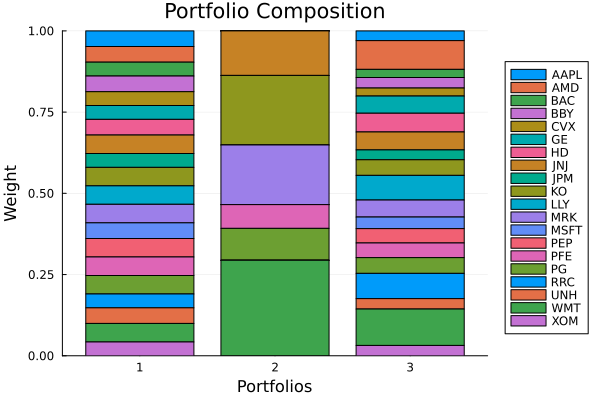

In [42]:
plot_stacked_bar_composition(ress, rd)

Dendrogram from the first nested-clustered result.

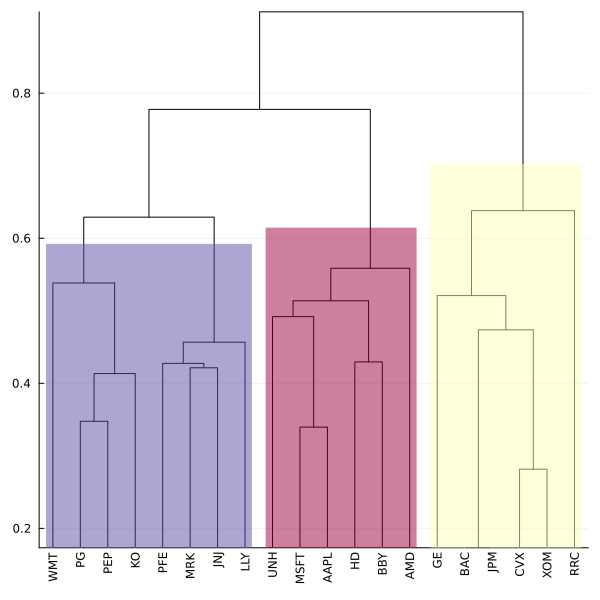

In [43]:
plot_dendrogram(ress[1].clr, rd.nx)

### 2.4 Stacking

The `Stacking` optimiser uses a similar approach to `NestedClustered`, but instead of using a single inner estimator, it uses a vector of estimators, inheriting the requirements of each estimator being used.

The inner weights matrix is constructed by horizontally concatenating the weights returned by optimising each inner estimator. The returns series used in the outer optimisation can be computed using the same approaches as in `NestedClustered`. The final weights are also computed the same way. It is also possible to provide a vector of weights by which to scale the weights of each inner estimator in order to bias the computation of the outer returns series in favour or against a particular estimator.

`Stacking` can take any non finite allocation optimiser as the inner or outer optimiser.

The keywords for the inner and outer optimisers are the same as `NestedClustered`.

In [44]:
# We'll use the same optimiser
opt = JuMPOptimiser(; slv = slv)

# Use a few different optimisation estimators
st = Stacking(;
              opti = [MeanRisk(; opt = opt), RiskBudgeting(; opt = opt),
                      InverseVolatility(), HierarchicalEqualRiskContribution()],
              opto = NearOptimalCentering(; opt = opt))

# Optimise estimator
res = optimise(st, rd);

Compute and view the results.

In [45]:
# Get the prior
pr = res.pr

# Construct the risk measure with the right covariance matrix
r = factory(StandardDeviation(), pr)

# Compute the risk, return, and risk adjusted return ratio
rk, rt, ratio = expected_risk_ret_ratio(r, ArithmeticReturn(), res.w, pr)

# Display asset weights
pretty_table(DataFrame(:assets => rd.nx, :Weights => res.w); formatters = [resfmt],
             title = "Composition")

# Display statistics
pretty_table(DataFrame(:Stat => ["Std", "Return", "Return/Std"],
                       :Measure => [rk, rt, ratio]); formatters = [resfmt],
             title = "Statistics")

     Composition
┌────────┬──────────┐
│ assets │  Weights │
│ String │  Float64 │
├────────┼──────────┤
│   AAPL │   0.06 % │
│    AMD │  0.039 % │
│    BAC │  0.069 % │
│    BBY │  0.055 % │
│    CVX │  0.069 % │
│     GE │  0.057 % │
│     HD │  0.068 % │
│    JNJ │ 13.224 % │
│    JPM │  0.078 % │
│     KO │ 19.816 % │
│    LLY │  0.072 % │
│    MRK │ 17.964 % │
│   MSFT │  0.063 % │
│    PEP │  0.082 % │
│      ⋮ │        ⋮ │
└────────┴──────────┘
       6 rows omitted
       Statistics
┌────────────┬─────────┐
│       Stat │ Measure │
│     String │ Float64 │
├────────────┼─────────┤
│        Std │ 1.187 % │
│     Return │ 0.057 % │
│ Return/Std │ 4.767 % │
└────────────┴─────────┘


Portfolio composition, cumulative returns vs the S&P 500 benchmark, and drawdown profile for the
stacking portfolio.

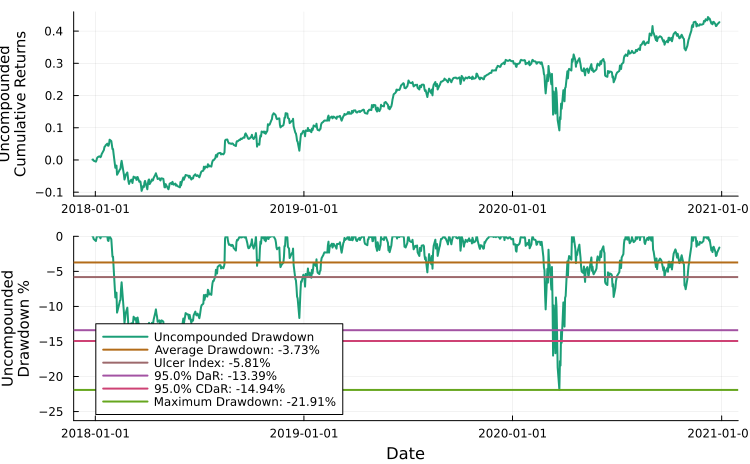

In [46]:
plot_composition(res, rd)
plot_benchmark(res, rd)
plot_drawdowns(res, rd)

### 2.5 Subset resampling

The `SubsetResampling` optimiser takes a given number of random asset subsets and optimises those subsets using the given optimiser. The final asset weights are the average weight per asset across all samples, if an asset does not appear in a sample, it is taken to be zero. It is possible to provide a `subset_size` keyword can be a float in `(0, 1)`, in which case it specifies a proportion of the data to use in each subset, or an integer which directly specifies subset size. It is also possible to provide a `n_subsets` keyword to specify the number of subsets to use.

In essence, this is almost an interpolation between the optimiser provided, and the `EqualWeighted` optimiser. If `subset_size` is `1`, and `n_subsets` is equal to the number of assets, the optimiser is equivalent to the `EqualWeighted` optimiser.

The samples are unique and drawn without replacement.

In [47]:
# We'll use the same optimiser
opt = JuMPOptimiser(; slv = slv)

# Mean risk for comparison
mr = MeanRisk(; opt = opt)

# Use 80% of the number of assets and take 10 samples
sr1 = SubsetResampling(; rng = StableRNG(666), subset_size = 0.8,
                       opt = MeanRisk(; opt = opt), n_subsets = 10)

# All weights are equal, the rng does not matter
sr2 = SubsetResampling(; subset_size = 1, opt = MeanRisk(; opt = opt),
                       n_subsets = size(rd.X, 2))

# Optimise all estimators at once using broadcasting
ress = optimise.([mr, sr1, sr2], rd);

Compute and view the results.

In [48]:
# All priors are the same so we can use the first one
pr = ress[1].pr

# Construct the risk measure with the right covariance matrix
r = factory(StandardDeviation(), pr)

# Compute the risk, return and risk adjusted return of all results
rk_rt_ratio = [expected_risk_ret_ratio(r, ArithmeticReturn(), res.w, pr) for res in ress]
rk = map(rr -> rr[1], rk_rt_ratio)
rt = map(rr -> rr[2], rk_rt_ratio)
ratio = map(rr -> rr[3], rk_rt_ratio)

# Display asset weights
pretty_table(DataFrame(:assets => rd.nx, :MeanRisk => ress[1].w,
                       :SubsetResampling => ress[2].w, :EqualWeighted => ress[3].w);
             formatters = [resfmt], title = "Composition")

# Display statistics
pretty_table(hcat(DataFrame(:Stat => ["Std", "Return", "Return/Std"]),
                  DataFrame(vcat(rk', rt', ratio'),
                            [:MeanRisk, :SubsetResampling, :EqualWeighted]));
             formatters = [resfmt])

                      Composition
┌────────┬──────────┬──────────────────┬───────────────┐
│ assets │ MeanRisk │ SubsetResampling │ EqualWeighted │
│ String │  Float64 │          Float64 │       Float64 │
├────────┼──────────┼──────────────────┼───────────────┤
│   AAPL │    0.0 % │          0.001 % │         5.0 % │
│    AMD │    0.0 % │            0.0 % │         5.0 % │
│    BAC │    0.0 % │            0.0 % │         5.0 % │
│    BBY │  0.001 % │          0.699 % │         5.0 % │
│    CVX │    0.0 % │          0.001 % │         5.0 % │
│     GE │    0.0 % │            0.0 % │         5.0 % │
│     HD │    0.0 % │          0.647 % │         5.0 % │
│    JNJ │ 13.325 % │          14.24 % │         5.0 % │
│    JPM │    0.0 % │            0.0 % │         5.0 % │
│     KO │ 20.013 % │         13.668 % │         5.0 % │
│    LLY │    0.0 % │          0.228 % │         5.0 % │
│    MRK │ 18.135 % │         22.194 % │         5.0 % │
│   MSFT │    0.0 % │            0.0 % │         5.0 %

Compositions for MeanRisk, SubsetResampling, and EqualWeighted — showing how subset resampling
interpolates between concentrated and equal-weight allocations.

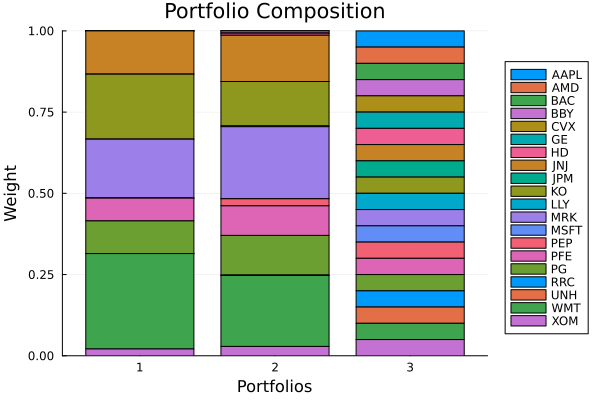

In [49]:
plot_stacked_bar_composition(ress, rd)

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*